In [2]:
!pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\pooja\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# 1. import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 2. LOAD DATASET
df = pd.read_csv("superstore.csv", encoding='latin1')


In [5]:
# 3. BASIC INFORMATION
print("First 5 Rows:\n", df.head())
print("\nColumns:\n", df.columns)
print("\nDataset Info:\n")
print(df.info())

First 5 Rows:
           Category         City        Country Customer.ID     Customer.Name  \
0  Office Supplies  Los Angeles  United States   LS-172304  Lycoris Saunders   
1  Office Supplies  Los Angeles  United States   MV-174854     Mark Van Huff   
2  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
3  Office Supplies  Los Angeles  United States   CS-121304      Chad Sievert   
4  Office Supplies  Los Angeles  United States   AP-109154    Arthur Prichep   

   Discount Market  è®°å½æ°               Order.Date        Order.ID  ...  \
0       0.0     US          1  2011-01-07 00:00:00.000  CA-2011-130813  ...   
1       0.0     US          1  2011-01-21 00:00:00.000  CA-2011-148614  ...   
2       0.0     US          1  2011-08-05 00:00:00.000  CA-2011-118962  ...   
3       0.0     US          1  2011-08-05 00:00:00.000  CA-2011-118962  ...   
4       0.0     US          1  2011-09-29 00:00:00.000  CA-2011-146969  ...   

  Sales   Segment            

In [10]:
# 4. DATA CLEANING

# Convert date columns
df['Order.Date'] = pd.to_datetime(df['Order.Date'])
df['Ship.Date'] = pd.to_datetime(df['Ship.Date'])


In [11]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [12]:
# Check missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
è®°å½æ°         0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64


In [14]:
# 5. FEATURE ENGINEERING

df['Year'] = df['Order.Date'].dt.year
df['Month'] = df['Order.Date'].dt.month
df['Month_Name'] = df['Order.Date'].dt.strftime('%b')


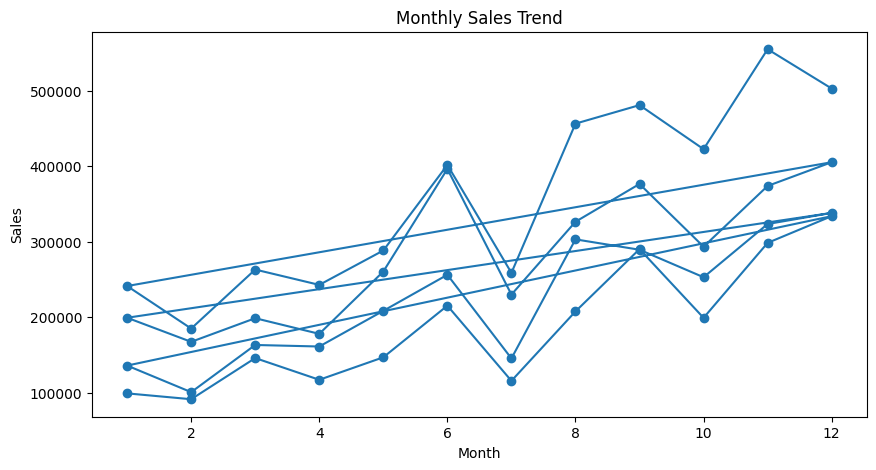

In [15]:
# 6. ANALYSIS & VISUALIZATION

# -------- 1. Monthly Sales Trend --------
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

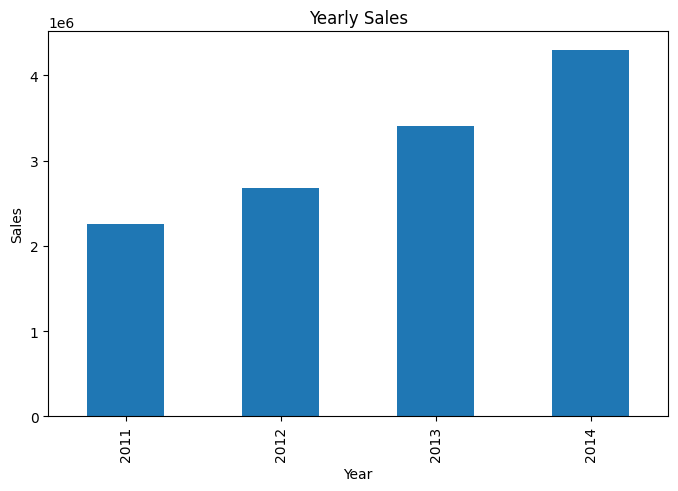

In [16]:
# -------- 2. Yearly Sales --------
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8,5))
yearly_sales.plot(kind='bar')
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()


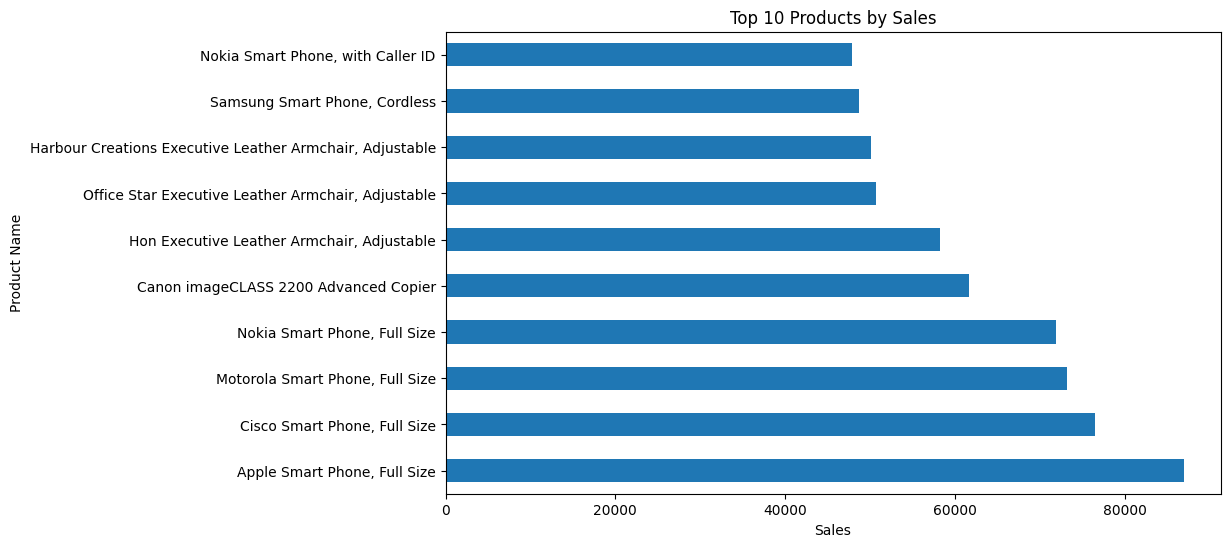

In [18]:
# -------- 3. Top 10 Products --------
top_products = df.groupby('Product.Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh')
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product.Name")
plt.show()

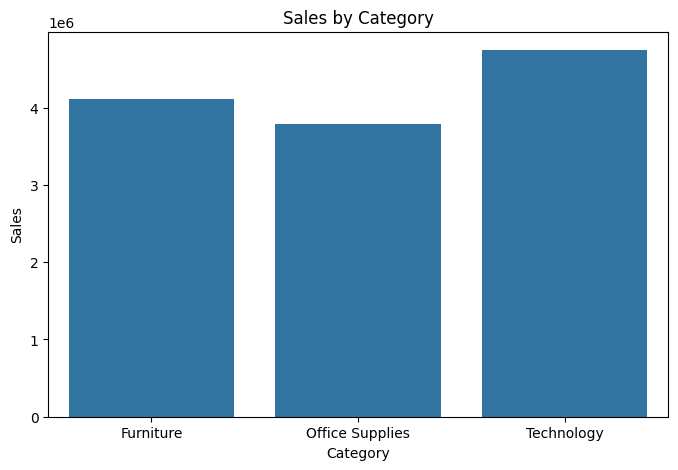

In [19]:
# -------- 4. Category-wise Sales --------
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=category_sales)
plt.title("Sales by Category")
plt.show()

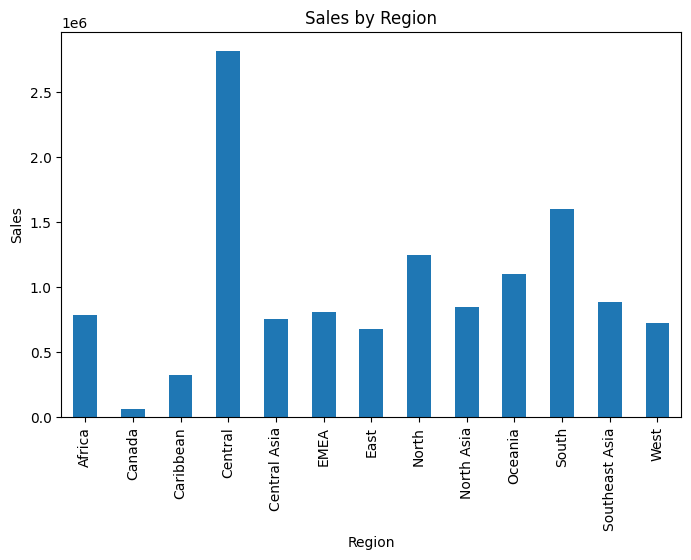

In [20]:
# -------- 5. Region-wise Sales --------
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

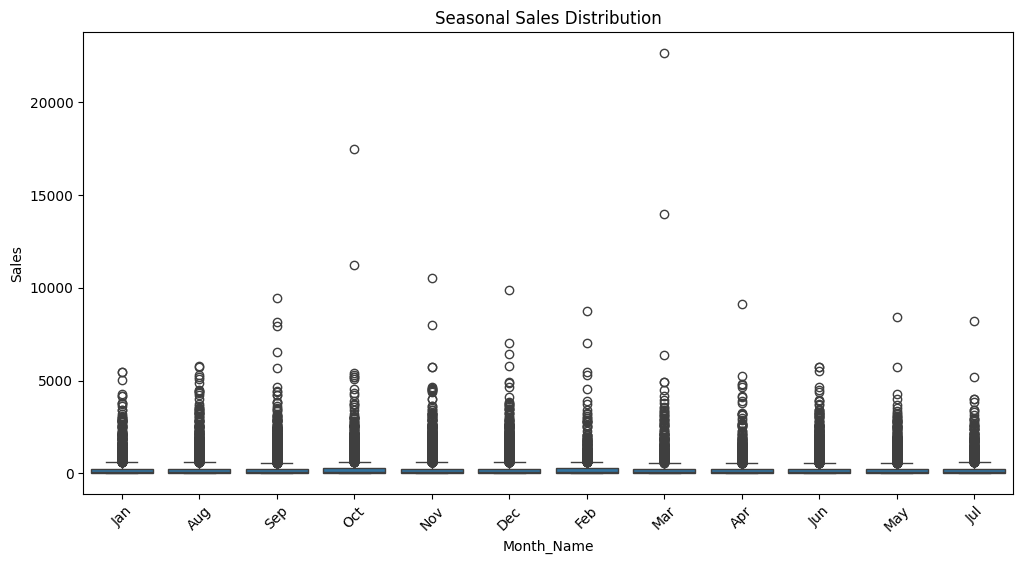

In [21]:
# -------- 6. Seasonal Analysis --------
plt.figure(figsize=(12,6))
sns.boxplot(x='Month_Name', y='Sales', data=df)
plt.title("Seasonal Sales Distribution")
plt.xticks(rotation=45)
plt.show()

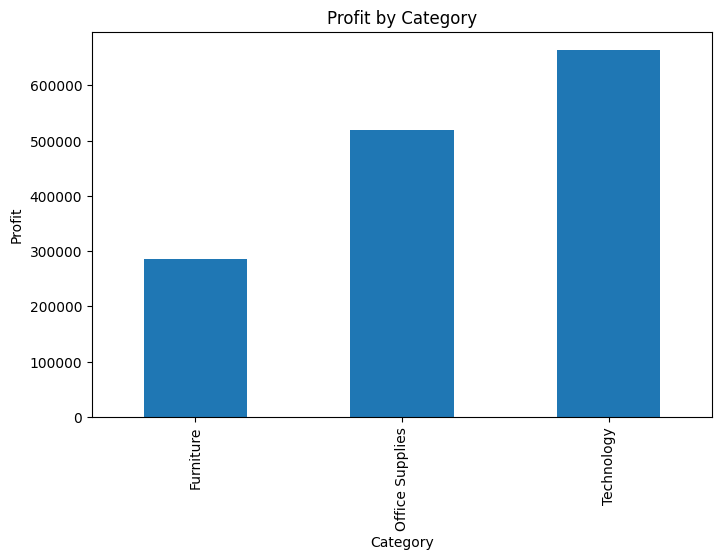

In [22]:
# -------- 7. Profit Analysis --------
profit_category = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,5))
profit_category.plot(kind='bar')
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

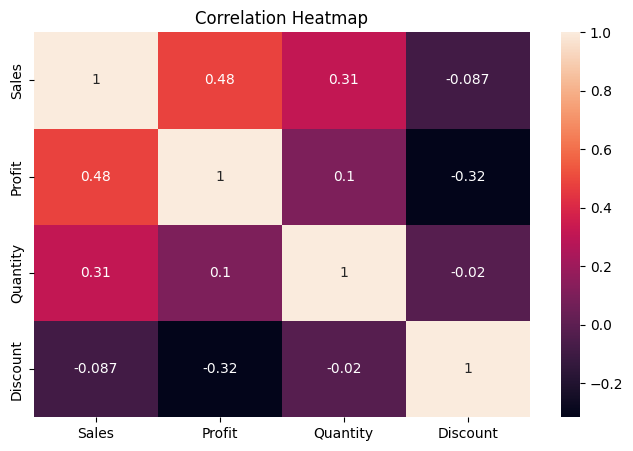

In [23]:
# -------- 8. Correlation Heatmap --------
plt.figure(figsize=(8,5))
sns.heatmap(df[['Sales','Profit','Quantity','Discount']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
# 7. SAVE CLEANED DATA

df.to_csv("cleaned_superstore.csv", index=False)

print("\n✅ Analysis Completed Successfully!")


✅ Analysis Completed Successfully!
